In [2]:
from modelscope.pipelines import pipeline
from modelscope.utils.constant import Tasks

inference_pipeline = pipeline(
    task=Tasks.auto_speech_recognition,
    model='iic/speech_paraformer-large_asr_nat-zh-cn-16k-common-vocab8404-pytorch', 
    model_revision="v2.0.4",
    )

rec_result = inference_pipeline(input='https://isv-data.oss-cn-hangzhou.aliyuncs.com/ics/MaaS/ASR/test_audio/asr_example_zh.wav', output_dir="./", disable_pbar=True)
print(rec_result)

/home/zhangjiayuan/miniconda3/envs/ali_modelscope/lib/python3.8/site-packages/modelscope/hub/snapshot_download.py Downloading Model to directory: /home/zhangjiayuan/.cache/modelscope/hub/iic/speech_paraformer-large_asr_nat-zh-cn-16k-common-vocab8404-pytorch


2025-06-30 08:49:34,623 - modelscope - INFO - Use user-specified model revision: v2.0.4
2025-06-30 08:49:35,322 - modelscope - INFO - initiate model from /home/zhangjiayuan/.cache/modelscope/hub/iic/speech_paraformer-large_asr_nat-zh-cn-16k-common-vocab8404-pytorch
2025-06-30 08:49:35,324 - modelscope - INFO - initiate model from location /home/zhangjiayuan/.cache/modelscope/hub/iic/speech_paraformer-large_asr_nat-zh-cn-16k-common-vocab8404-pytorch.
2025-06-30 08:49:35,380 - modelscope - INFO - initialize model from /home/zhangjiayuan/.cache/modelscope/hub/iic/speech_paraformer-large_asr_nat-zh-cn-16k-common-vocab8404-pytorch


funasr version: 1.2.2.
Check update of funasr, and it would cost few times. You may disable it by set `disable_update=True` in AutoModel
New version is available: 1.2.6.
Please use the command "pip install -U funasr" to upgrade.
Loading pretrained params from /home/zhangjiayuan/.cache/modelscope/hub/iic/speech_paraformer-large_asr_nat-zh-cn-16k-common-vocab8404-pytorch/model.pt


2025-06-30 08:49:48,159 - modelscope - WARNING - No preprocessor field found in cfg.
2025-06-30 08:49:48,161 - modelscope - WARNING - No val key and type key found in preprocessor domain of configuration.json file.
2025-06-30 08:49:48,161 - modelscope - WARNING - Cannot find available config to build preprocessor at mode inference, current config: {'model_dir': '/home/zhangjiayuan/.cache/modelscope/hub/iic/speech_paraformer-large_asr_nat-zh-cn-16k-common-vocab8404-pytorch'}. trying to build by task and model information.
2025-06-30 08:49:48,162 - modelscope - WARNING - No preprocessor key ('funasr', 'auto-speech-recognition') found in PREPROCESSOR_MAP, skip building preprocessor.


[{'key': 'asr_example_zh', 'text': '欢迎大家来体验达摩院推出的语音识别模型', 'score': -1.6472185850143433, 'wd_score': [0.9250594973564148, 0.9361027479171753, 0.8952967524528503, 0.8971680402755737, 0.8945184350013733, 0.9131760597229004, 0.9476251006126404, 0.9358212947845459, 0.9448878169059753, 0.9279370903968811, 0.9370487928390503, 0.8969293236732483, 0.8957635760307312, 0.9339223504066467, 0.9308863282203674, 0.9434126615524292, 0.9074532389640808, 0.9311461448669434, 0.9277999997138977]}]


In [ ]:
model_dir = '/home/zhangjiayuan/.cache/modelscope/hub/iic/speech_paraformer-large-vad-punc_asr_nat-zh-cn-16k-common-vocab8404-pytorch/'

from modelscope.pipelines import pipeline
from modelscope.utils.constant import Tasks

inference_pipeline = pipeline(
    task=Tasks.auto_speech_recognition,
    model=model_dir, 
    )

rec_result = inference_pipeline(input='https://isv-data.oss-cn-hangzhou.aliyuncs.com/ics/MaaS/ASR/test_audio/asr_example_zh.wav', output_dir="./", disable_pbar=True)
print(rec_result)

In [16]:
from funasr import AutoModel
import soundfile as sf

model_dir = '/home/zhangjiayuan/.cache/modelscope/hub/iic/speech_paraformer-large-vad-punc_asr_nat-zh-cn-16k-common-vocab8404-pytorch/'

model = AutoModel(model=model_dir, model_revision="v2.0.4", device='cuda:1')




wav_file = '/home/zhangjiayuan/temp/audio/kefu_badcase/first1.wav'      # 你好 高兴为您服务 请什么可以帮您

speech, fs = sf.read(wav_file)
cache = {}
res = model.generate(input=speech, cache=cache)

print(res)
print(cache.keys())


res = model.generate(input=[wav_file,wav_file], disable_pbar = True,)
print(res)


funasr version: 1.2.2.
Check update of funasr, and it would cost few times. You may disable it by set `disable_update=True` in AutoModel


New version is available: 1.2.6.
Please use the command "pip install -U funasr" to upgrade.
Loading pretrained params from /home/zhangjiayuan/.cache/modelscope/hub/iic/speech_paraformer-large-vad-punc_asr_nat-zh-cn-16k-common-vocab8404-pytorch/model.pt


rtf_avg: 3.730: 100%|██████████| 1/1 [00:07<00:00,  7.65s/it]                                                                                          

[{'key': 'rand_key_2yW4Acq9GFz6Y', 'text': '您 好 高 兴 为 的 服 务 请 什 么 帮 您', 'timestamp': [[250, 390], [390, 570], [570, 670], [670, 790], [790, 910], [910, 990], [990, 1070], [1070, 1170], [1170, 1290], [1290, 1370], [1370, 1470], [1470, 1590], [1590, 1855]], 'scores': [0.557772159576416, 0.892456591129303, 0.6018033027648926, 0.888119101524353, 0.4743073582649231, 0.7462533712387085, 0.909034252166748, 0.929046630859375, 0.6832396984100342, 0.703279435634613, 0.7377738952636719, 0.9016004800796509, 0.8990105390548706], 'pre_token_num': 14, 'pre_token_num2': 12.951108932495117}]
dict_keys([])


[{'key': 'first1', 'text': '您 好 高 兴 我 的 服 务 请 什 么 帮 您', 'timestamp': [[250, 390], [390, 570], [570, 670], [670, 790], [790, 910], [910, 990], [990, 1070], [1070, 1170], [1170, 1290], [1290, 1370], [1370, 1470], [1470, 1590], [1590, 1855]], 'scores': [0.5437362790107727, 0.8933559656143188, 0.5330252647399902, 0.878547728061676, 0.5011531114578247, 0.7714932560920715, 0.9117208123207092, 0.9294537305831909, 0.6842846274375916, 0.7258222103118896, 0.7446162700653076, 0.9013988375663757, 0.8978301286697388], 'pre_token_num': 14, 'pre_token_num2': 12.954645156860352}, {'key': 'first1', 'text': '您 好 高 兴 我 的 服 务 请 什 么 帮 您', 'timestamp': [[250, 390], [390, 570], [570, 670], [670, 790], [790, 910], [910, 990], [990, 1070], [1070, 1170], [1170, 1290], [1290, 1370], [1370, 1470], [1470, 1590], [1590, 1855]], 'scores': [0.4939621388912201, 0.8952995538711548, 0.5122061967849731, 0.8487931489944458, 0.605063796043396, 0.8209507465362549, 0.9160284399986267, 0.9283841252326965, 0.6833502054214478, 

In [17]:

device = next(model.model.parameters()).device
print(device)
print(res[0].keys())

cuda:1
dict_keys(['key', 'text', 'timestamp', 'scores', 'pre_token_num', 'pre_token_num2'])


In [4]:
from funasr import AutoModel
import soundfile as sf

wav_file = '/home/zhangjiayuan/temp/audio/kefu_badcase/lost_offline/speech-1912372181595549696.wav'      # 你好 高兴为您服务 请什么可以帮您


model_dir = '/data/nas/shared//model_test/'

model = AutoModel(model=model_dir)

res = model.generate(input=wav_file)

print(res)



model_dir2 = '/home/zhangjiayuan/.cache/modelscope/hub/iic/speech_paraformer-large-vad-punc_asr_nat-zh-cn-16k-common-vocab8404-pytorch/'
model2 = AutoModel(model=model_dir2, model_revision="v2.0.4",)
res = model2.generate(input=wav_file)

print(res)





funasr version: 1.2.2.
Check update of funasr, and it would cost few times. You may disable it by set `disable_update=True` in AutoModel
New version is available: 1.2.6.
Please use the command "pip install -U funasr" to upgrade.


rtf_avg: 0.190: 100%|██████████| 1/1 [00:00<00:00,  3.72it/s]                                                                                          


[{'key': 'speech-1912372181595549696', 'text': '没 有 收 到', 'timestamp': [[30, 90], [90, 170], [170, 270], [270, 510]]}]
funasr version: 1.2.2.
Check update of funasr, and it would cost few times. You may disable it by set `disable_update=True` in AutoModel
New version is available: 1.2.6.
Please use the command "pip install -U funasr" to upgrade.


rtf_avg: 0.076: 100%|██████████| 1/1 [00:00<00:00,  6.53it/s]                                                                                          

[{'key': 'speech-1912372181595549696', 'text': '没 有 收 到 嗯', 'timestamp': [[30, 110], [110, 190], [190, 290], [290, 530], [1150, 1320]]}]


In [14]:
from funasr_onnx import Paraformer
import numpy as np
import struct
import glob

def read_vector_from_file(filename):
    with open(filename, 'rb') as f:
        size_bytes = f.read(4)
        size = struct.unpack('<I', size_bytes)[0]  # 小端字节序
        data = np.frombuffer(f.read(size * 4), dtype=np.float32)
    return data

wave_file = '/data/nas/zhangjiayuan/program/yto/yto-asr-core/asr-engine/runtime/asr_core_service/bin/debug_wavs_20250407_074840.bin'
wave = read_vector_from_file(wave_file)
print(f'wave: {wave.shape} , shape  {type(wave)} , dtype {wave.dtype}')
model_dir = '/data/nas/shared/model_test'
model = Paraformer(model_dir, quantize=True)

res = model(wave)
print(res)

wave: (23680,) , shape  <class 'numpy.ndarray'> , dtype float32
[{'preds': '对 呀', 'timestamp': [[630, 950], [950, 1500]], 'raw_tokens': ['对', '呀']}]


In [12]:
from funasr_onnx import Paraformer
from funasr import AutoModel
import librosa

wav_file = '/home/zhangjiayuan/temp/audio/kefu_badcase/lost_offline/speech-1912372181595549696.wav' 
wav_file = '/home/zhangjiayuan/temp/audio/kefu_badcase/lost_offline/speech-1912679249531596800.wav' 
# wav_file = '/home/zhangjiayuan/temp/audio/kefu_badcase/lost_offline/speech-1912679249531596800-1.wav' 

speech, _ = librosa.load(wav_file, sr=16000)
speech_chunk = speech[:-16*100]

model_dir = '/workspace/models_new/damo/speech_paraformer-large-vad-punc_asr_nat-zh-cn-16k-common-vocab8404-onnx'
model_dir2 = '/home/zhangjiayuan/.cache/modelscope/hub/iic/speech_paraformer-large-vad-punc_asr_nat-zh-cn-16k-common-vocab8404-pytorch/'
model_dir = '/data/nas/shared/model_test'
model = Paraformer(model_dir, quantize=True)

print(speech.shape)
res = model(speech)
print(res)




model_dir = '/home/zhangjiayuan/.cache/modelscope/hub/iic/speech_paraformer-large-vad-punc_asr_nat-zh-cn-16k-common-vocab8404-pytorch'
py_model = AutoModel(model=model_dir, disable_update=True)
res = py_model.generate(input=[speech,speech_chunk], batch_size=2)
print(res)

(14400,)
[{'preds': '收 到 了', 'timestamp': [[50, 130], [130, 230], [230, 900]], 'raw_tokens': ['收', '到', '了']}]
funasr version: 1.2.2.
Loading pretrained params from /home/zhangjiayuan/.cache/modelscope/hub/iic/speech_paraformer-large-vad-punc_asr_nat-zh-cn-16k-common-vocab8404-pytorch/model.pt


rtf_avg: 0.072: 100%|██████████| 2/2 [00:00<00:00, 14.20it/s]                                                                                          

[{'key': 'rand_key_2yW4Acq9GFz6Y', 'text': '', 'timestamp': []}, {'key': 'rand_key_2yW4Acq9GFz6Y', 'text': '知 道 了', 'timestamp': [[30, 90], [90, 170], [170, 505]]}]


(20800,)
(19200,)


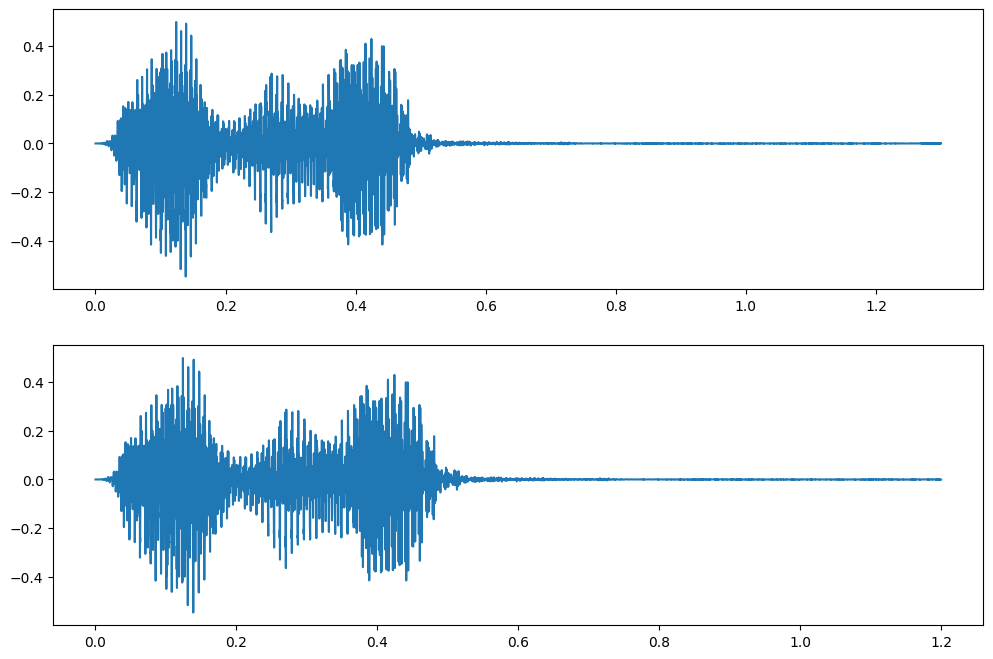

In [24]:
from IPython.display import Audio
import numpy as np
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8)) 

print(speech.shape)
axis_x = np.arange(len(speech))/16000
ax1.plot(axis_x, speech)

print(speech_chunk.shape)
axis_x = np.arange(len(speech_chunk))/16000
ax2.plot(axis_x, speech_chunk)

plt.show()
Audio(speech_chunk, rate=16000)

(40000,) <class 'numpy.ndarray'>
(152000,)


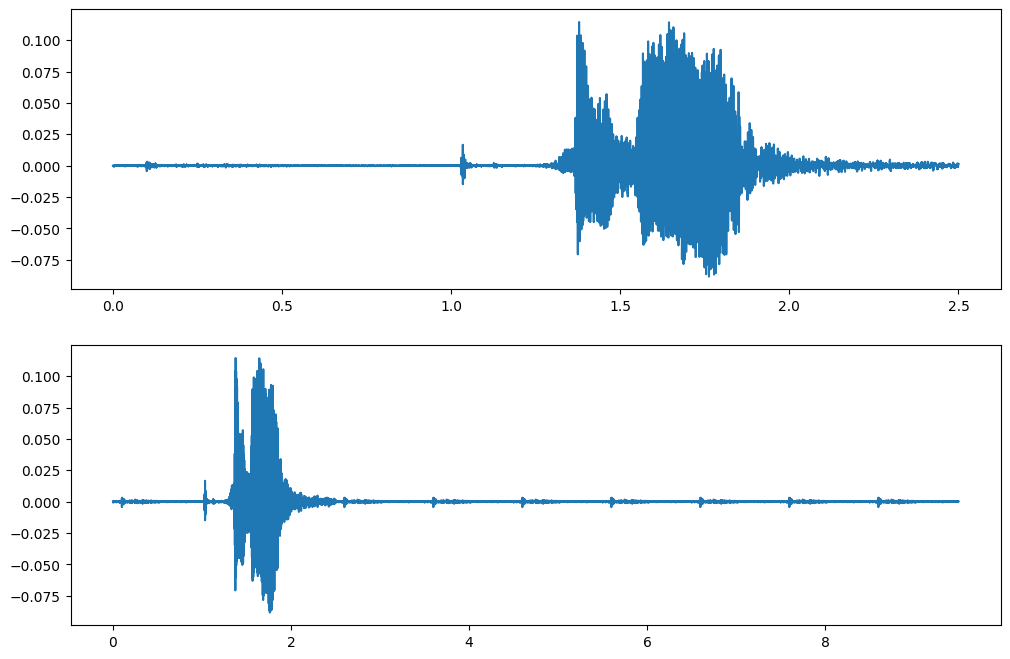

[{'preds': '然 后', 'timestamp': [[1410, 1670], [1670, 2520]], 'raw_tokens': ['然', '后']}]
[{'preds': '然 后', 'timestamp': [[1410, 1690], [1690, 5735]], 'raw_tokens': ['然', '后']}]


In [44]:
from IPython.display import Audio
import numpy as np
import matplotlib.pyplot as plt
import librosa
import soundfile as sf


wav_file = '/home/zhangjiayuan/temp/audio/a.wav'

speech, fs = sf.read(wav_file)
speech = speech[int(88*fs):int(90.5*fs)]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8)) 

print(speech.shape, type(speech))
axis_x = np.arange(len(speech))/16000
ax1.plot(axis_x, speech)



speech2 = np.concatenate([speech, speech[:fs],speech[:fs],speech[:fs],speech[:fs],speech[:fs],speech[:fs],speech[:fs]])
print(speech2.shape)
axis_x = np.arange(len(speech2))/16000
ax2.plot(axis_x, speech2)


plt.show()



res = model(speech)
print(res)

res = model(speech2)
print(res)

# 模型导出

In [1]:
from funasr import AutoModel

model_dir = '/data/nas/shared/model_test/'

model_dir = '/workspace/models_new/damo/model2_ep15'

model_dir = '/data/nas/zhangjiayuan/experiment/paraformer_finitune/exp6_1/exp1_lora/exp/finetune1_all_lora/'

model_dir = '/workspace/models_new/damo/model4_ep21/'

model_dir = '/workspace/models_new/damo/model4_avg10_mergedLora/'

model = AutoModel(model=model_dir, init_param=f'{model_dir}/model_mergedLora.pt')

res = model.export(quantize=True)


-------debug------ /home/zhangjiayuan/miniconda3/envs/ali_modelscope/lib/python3.8/ctypes/__init__.py:  Failed to load library '/home/zhangjiayuan/miniconda3/envs/ali_modelscope/lib/python3.8/site-packages/torio/lib/libtorio_ffmpeg6.so'. Error: libavutil.so.58: cannot open shared object file: No such file or directory
-------debug------ /home/zhangjiayuan/miniconda3/envs/ali_modelscope/lib/python3.8/ctypes/__init__.py:  Failed to load library '/home/zhangjiayuan/miniconda3/envs/ali_modelscope/lib/python3.8/site-packages/torio/lib/libtorio_ffmpeg5.so'. Error: libavutil.so.57: cannot open shared object file: No such file or directory
funasr version: 1.2.2.
Check update of funasr, and it would cost few times. You may disable it by set `disable_update=True` in AutoModel
New version is available: 1.2.6.
Please use the command "pip install -U funasr" to upgrade.
Loading pretrained params from /workspace/models_new/damo/model4_avg10_mergedLora//model_mergedLora.pt
Quantizing model from /works

In [14]:
model_dir = '/workspace/models_new/damo/model3_ep23/'


model = AutoModel(model=model_dir, init_param=f'{model_dir}/model.pt.ep21', device='cuda:1')

res = model.export(quantize=True, type="bladedisc")

funasr version: 1.2.2.
Check update of funasr, and it would cost few times. You may disable it by set `disable_update=True` in AutoModel
New version is available: 1.2.6.
Please use the command "pip install -U funasr" to upgrade.
error, init_param does not exist!: /workspace/models_new/damo/model3_ep23//model.pt.ep21
rescale encoder modules with factor=0


Warning, if you are exporting bladedisc, please install it and try it again: pip install -U torch_blade



UnboundLocalError: local variable 'torch_blade' referenced before assignment

# 模型测试

In [ ]:
import os
import glob
from funasr_onnx import Paraformer
import numpy as np
import struct

def get_files(in_dir='/workspace/debug_wavs/', suffix='.bin'):
    return glob.glob(os.path.join(in_dir, f"*{suffix}"), recursive=True)

def read_debug_wav(filename):
    with open(filename, 'rb') as f:
        size_bytes = f.read(4)
        size = struct.unpack('<I', size_bytes)[0]  # 小端字节序
        data = np.frombuffer(f.read(size * 4), dtype=np.float32)
    return data


model_dir = '/data/nas/shared/model_test'
asr_model1 = Paraformer(model_dir, quantize=True)
model_dir = '/workspace/models_new/damo/speech_paraformer-large-vad-punc_asr_nat-zh-cn-16k-common-vocab8404-onnx'
asr_model2 = Paraformer(model_dir, quantize=True)




debug_wavs = get_files()
print(debug_wavs)

for debug_wav_file in debug_wavs:
    utt = debug_wav_file.split('/')[-1]
    wave = read_debug_wav(debug_wav_file)
    res1 = asr_model1(wave)
    res2 = asr_model2(wave)
    print(f'{utt} \n\t{res1} \n\t{res2}')
    

In [17]:
from IPython.display import Audio

speech = read_debug_wav('/workspace/debug_wavs/badcase_wavs_20250424_103012_82537.bin')

Audio(speech, rate=16000)

跑一个测试集

In [31]:
from funasr import AutoModel
from funasr_onnx import Paraformer
import soundfile as sf

def read_wav_scp(scp_file):
    utts = []
    wav2scp = {}
    
    with open(scp_file, 'r', encoding='utf-8') as f:
        for line in f:
            utt, wav_path = line.strip().split()
            utts.append(utt)
            wav2scp[utt] = wav_path
    
    return utts, wav2scp


wav_scp_file = '/data/nas/dataset/asr-train/kefu_train/huaian_biaobei_data01/data/test/wav.scp'

model_dir = '/workspace/models_new/damo/model_ep15'
asr_model = Paraformer(model_dir, quantize=True)

py_model = AutoModel(model=model_dir, disable_update=True)

utts, wav2scp = read_wav_scp(wav_scp_file)


wav_file = wav2scp[utts[0]]

speech, fs = sf.read(wav_file)
res = asr_model(speech)
txt = res[0]['preds']
print(txt)

res = py_model.generate(speech, disable_pbar=True)
txt = res[0]['text']
print(txt)


funasr version: 1.2.2.
Loading pretrained params from /workspace/models_new/damo/model_ep15/model.pt
你 好
你 好


In [28]:
my_list = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

a = my_list[0:-1:3]
print(a)

b = [my_list[st::3] for st in range(3)]
print(b)

[1, 4, 7]
[[1, 4, 7, 10], [2, 5, 8], [3, 6, 9]]


In [38]:
model_root_dir = '/data/nas/zhangjiayuan/experiment/paraformer_finitune/exp6_1/exp1_lora/exp/finetune1_all_lora'

print(os.path.basename(model_root_dir))
print(os.path.dirname(model_root_dir))

finetune1_all_lora
/data/nas/zhangjiayuan/experiment/paraformer_finitune/exp6_1/exp1_lora/exp


## 将测试集放到圆通平台做一下质检， 顺便把汉字数字转换成阿拉伯数字

# 模型导出 GPU 格式

In [12]:
from funasr import AutoModel
import soundfile as sf

# model_dir = '/home/zhangjiayuan/.cache/modelscope/hub/iic/speech_paraformer-large-vad-punc_asr_nat-zh-cn-16k-common-vocab8404-pytorch/'

model = AutoModel(model="iic/speech_paraformer-large-vad-punc_asr_nat-zh-cn-16k-common-vocab8404-pytorch", model_revision="v2.0.4",)



funasr version: 1.2.2.
Check update of funasr, and it would cost few times. You may disable it by set `disable_update=True` in AutoModel


New version is available: 1.2.6.
Please use the command "pip install -U funasr" to upgrade.


2025-05-21 05:41:20,557 - modelscope - INFO - Use user-specified model revision: v2.0.4


Loading pretrained params from /home/zhangjiayuan/.cache/modelscope/hub/iic/speech_paraformer-large-vad-punc_asr_nat-zh-cn-16k-common-vocab8404-pytorch/model.pt


In [8]:
from funasr.download.runtime_sdk_download_tool import main
import sys


sys.argv = [
    "../funasr/download/runtime_sdk_download_tool.py",  # 脚本名占位
    "--model-name", "damo/speech_paraformer-large-vad-punc_asr_nat-zh-cn-16k-common-vocab8404",
    "--export-dir", "./temp/",
    "--export", "True",
    "--type", "onnx",
    "--device", "cuda",
    "--quantize", "False"
]

main()

2025-05-21 05:12:29,785 - modelscope - ERROR - The request model: damo/speech_paraformer-large-vad-punc_asr_nat-zh-cn-16k-common-vocab8404 does not exist!


TypeError: exceptions must derive from BaseException